In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
import geopandas as gpd
import sys
import pickle
import json

sys.path.insert(0, "../../../utils")

from modules import *

import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

REGION = 'ExtNord'

ΤARGET = ""  # "_und5", "_ovr5", "_prgn", "_severe", "_hospitalization" or ""

In [2]:
target_variable = {"": "Total Malaria Cases",
                   "_und5": "Malaria Cases Under 5 Years",
                   "_ovr5": "Malaria Cases Over 5 Years",
                   "_prgn": "Malaria Cases in Pregnant Women",
                   "_severe": "Total Severe Malaria Cases",
                   "_hospitalization": "Total Malaria Hospitalizations"}

In [3]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Test_Dataset_2015-2025.csv', encoding=enc)

In [4]:
dataframe

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2015-01,2015,1,0.5,...,34.33,28.83,1345,483,0,143.14,1072,0,85,911
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2015-01,2015,1,0.5,...,35.00,29.33,1228,422,0,140.46,982,0,91,784
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2015-01,2015,1,0.5,...,34.17,27.33,1324,475,0,144.61,1070,0,74,701
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2015-01,2015,1,0.5,...,33.83,27.00,1301,476,0,144.58,1048,0,63,693
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2015-01,2015,1,0.5,...,34.17,28.17,1268,440,0,142.37,1023,0,180,1023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41839,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2025-12,2025,12,0.0,...,31.50,25.33,1941,597,0,135.39,1464,1,61,158
41840,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,2025-12,2025,12,0.0,...,31.83,25.50,1894,590,0,136.08,1434,1,56,1
41841,extreme nord,mayo-tsanaga,roua,roua,13.968570,10.779370,2025-12,2025,12,0.0,...,33.00,25.83,1968,607,0,135.57,1507,1,58,1
41842,extreme nord,mayo-tsanaga,roua,soulede,13.917498,10.736254,2025-12,2025,12,0.0,...,32.67,25.00,1969,604,0,135.14,1498,2,60,2


In [5]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location_full'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location', 'location_full'] + dataframe.columns.to_list()[:-2]]

In [6]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [7]:
inference = dataframe[dataframe["dt_prediction"] > pd.Period("2024-09", freq="M")]
inference.reset_index(drop=True, inplace=True)

inference.head()

,location,location_full,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"(extreme nord, bogo, balaza)","(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2024-10,-0.866,0.5,0.377319,-0.022331,-0.351487,...,36.00,28.00,1400,457,0,121.31,944,0,150,890
1,"(extreme nord, bogo, balda)","(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2024-10,-0.866,0.5,0.354336,-0.084411,-0.340380,...,36.33,27.67,1373,452,0,123.78,943,0,131,890
2,"(extreme nord, bogo, bogo)","(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2024-10,-0.866,0.5,0.365004,-0.053135,-0.358651,...,34.83,28.33,1415,464,0,121.63,939,0,134,924
3,"(extreme nord, bogo, borai)","(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2024-10,-0.866,0.5,0.364578,0.034294,-0.333879,...,35.00,28.00,1475,464,0,117.63,962,0,162,949
4,"(extreme nord, bogo, guinggley)","(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2024-10,-0.866,0.5,0.390559,0.010424,-0.367982,...,35.33,28.00,1449,475,0,121.57,964,0,135,947


In [8]:
with open(f'saved/CM_{REGION}_bin_ranges{ΤARGET}.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 9


In [9]:
with open(f"saved/CM_{REGION}_rfecv_model{ΤARGET}.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

with open(f"saved/CM_{REGION}_scaler{ΤARGET}.pkl", "rb") as f:
    fitted_scaler = pickle.load(f)

with open(f"saved/CM_{REGION}_imputer{ΤARGET}.pkl", "rb") as f:
    fitted_imputer = pickle.load(f)

with open(f"saved/CM_{REGION}_xgb_model{ΤARGET}.pkl", "rb") as f:
    fitted_model = pickle.load(f)

In [10]:
X_test = inference.select_dtypes(exclude=['object', 'period[M]'])
X_test.head()

,x,y,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,14.515776,10.786560,-0.866,0.5,0.377319,-0.022331,-0.351487,0.022331,0.367593,-0.031104,...,36.00,28.00,1400,457,0,121.31,944,0,150,890
1,14.724237,10.914551,-0.866,0.5,0.354336,-0.084411,-0.340380,0.084411,0.347946,-0.050915,...,36.33,27.67,1373,452,0,123.78,943,0,131,890
2,14.597860,10.743440,-0.866,0.5,0.365004,-0.053135,-0.358651,0.053135,0.368767,-0.033106,...,34.83,28.33,1415,464,0,121.63,939,0,134,924
3,14.606980,10.653607,-0.866,0.5,0.364578,0.034294,-0.333879,-0.034294,0.384466,0.009838,...,35.00,28.00,1475,464,0,117.63,962,0,162,949
4,14.702740,10.792848,-0.866,0.5,0.390559,0.010424,-0.367982,-0.010424,0.385293,-0.017150,...,35.33,28.00,1449,475,0,121.57,964,0,135,947


In [11]:
X_test_scaled = pd.DataFrame(fitted_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [12]:
X_test_imputed = pd.DataFrame(fitted_imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [13]:
X_test_imputed = pd.DataFrame(fitted_scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [14]:
X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X_test.columns[fitted_rfe.support_], index=X_test.index)

In [15]:
y_test_pred = fitted_model.predict(X_test_rfe)

In [16]:
y_test_pred = np.clip(np.round(y_test_pred), 0, num_of_classes -1).astype(int)

In [17]:
y_test_pred

array([7, 6, 7, ..., 4, 3, 3])

In [18]:
results_test = pd.DataFrame({'prediction': y_test_pred})

results_test['dt_prediction'] = inference.loc[results_test.index, 'dt_prediction']
results_test['dt_reference'] = results_test['dt_prediction']+3

results_test.reset_index(drop=True, inplace=True)

In [19]:
results_test

,prediction,dt_prediction,dt_reference
0,7,2024-10,2025-01
1,6,2024-10,2025-01
2,7,2024-10,2025-01
3,5,2024-10,2025-01
4,6,2024-10,2025-01
...,...,...,...
4750,3,2025-12,2026-03
4751,3,2025-12,2026-03
4752,4,2025-12,2026-03
4753,3,2025-12,2026-03


In [20]:
results_df = pd.merge(inference[['location', 'location_full', 'x', 'y']], results_test, left_index=True, right_index=True, how='inner')
results_df['classes_range'] = num_of_classes-1
results_df['target'] = target_variable[ΤARGET]

In [21]:
polygon_ids = pd.read_csv(f'../../../data/CM_WEB_Polygons_processed.csv', encoding=enc)

polygon_ids['location'] = polygon_ids['location'].astype(str)
results_df['location'] = results_df['location'].astype(str)

In [22]:
results_df = pd.merge(results_df, polygon_ids, on=['location'], how='left')
results_df.drop(columns=['location'], inplace=True)
results_df.rename(columns={'location_full': 'location', 'id': 'polygon_id'}, inplace=True)
results_df = results_df[['location', 'polygon_id', 'x', 'y', 'target', 'classes_range', 'dt_prediction', 'dt_reference', 'prediction']]

In [23]:
results_df = results_df[['location', 'polygon_id', 'x', 'y', 'target', 'classes_range', 'dt_prediction', 'dt_reference', 'prediction']]

In [24]:
results_df

,location,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction
0,"(extreme nord, diamare, bogo, balaza)",372,14.515776,10.786560,Total Malaria Cases,8,2024-10,2025-01,7
1,"(extreme nord, diamare, bogo, balda)",310,14.724237,10.914551,Total Malaria Cases,8,2024-10,2025-01,6
2,"(extreme nord, diamare, bogo, bogo)",311,14.597860,10.743440,Total Malaria Cases,8,2024-10,2025-01,7
3,"(extreme nord, diamare, bogo, borai)",313,14.606980,10.653607,Total Malaria Cases,8,2024-10,2025-01,5
4,"(extreme nord, diamare, bogo, guinggley)",312,14.702740,10.792848,Total Malaria Cases,8,2024-10,2025-01,6
...,...,...,...,...,...,...,...,...,...
4750,"(extreme nord, mayo-tsanaga, roua, midre)",367,13.871290,10.791350,Total Malaria Cases,8,2025-12,2026-03,3
4751,"(extreme nord, mayo-tsanaga, roua, ndimche)",428,13.968570,10.827287,Total Malaria Cases,8,2025-12,2026-03,3
4752,"(extreme nord, mayo-tsanaga, roua, roua)",411,13.968570,10.779370,Total Malaria Cases,8,2025-12,2026-03,4
4753,"(extreme nord, mayo-tsanaga, roua, soulede)",368,13.917498,10.736254,Total Malaria Cases,8,2025-12,2026-03,3


<Axes: title={'center': 'Predicted Case Bin Distribution'}, xlabel='Bins', ylabel='Frequency'>

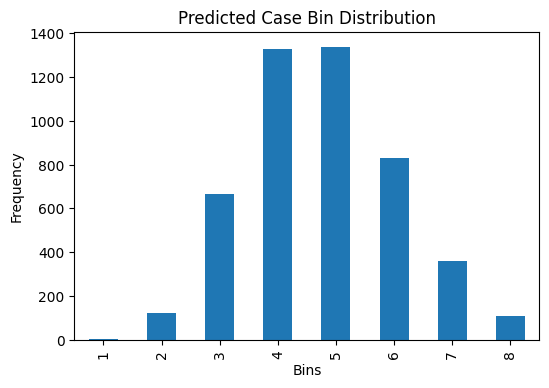

In [25]:
results_df.prediction.value_counts().sort_index().plot(kind='bar', 
                                                              figsize=(6, 4), 
                                                              title='Predicted Case Bin Distribution', 
                                                              xlabel='Bins', 
                                                              ylabel='Frequency')

In [33]:
period = "2026-03"

test_results_to_send = results_df[results_df["dt_reference"] == pd.Period(period, freq="M")]
test_results_to_send.to_csv(f'../../../data/{REGION}/results/CM_{REGION}_Inference_{period}{ΤARGET}.csv', index=False, encoding=enc)

<Axes: title={'center': 'Predicted Case Bin Distribution'}, xlabel='Bins', ylabel='Frequency'>

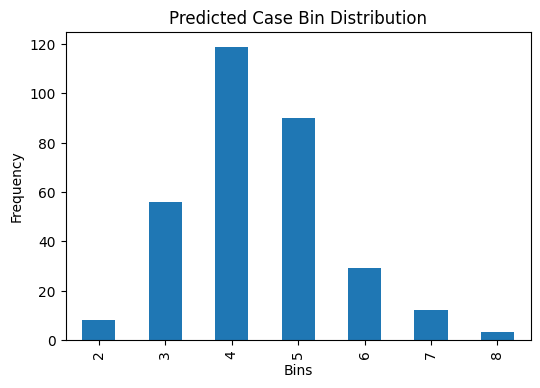

In [34]:
test_results_to_send.prediction.value_counts().sort_index().plot(kind='bar', 
                                                              figsize=(6, 4), 
                                                              title='Predicted Case Bin Distribution', 
                                                              xlabel='Bins', 
                                                              ylabel='Frequency')

In [35]:
shapefile_path = "../../../../../../Shapefiles/Cameroon Shapefiles/new/"
shapefile = gpd.read_file(f"{shapefile_path}web_platform/CM_ExtremeNord_LV3.shp",  encoding=enc)

shapefile['location'] = list(zip(shapefile['GID0'],shapefile['GID1'], shapefile['GID2'], shapefile['GID3']))

In [36]:
results_shapefile = gpd.GeoDataFrame(pd.merge(test_results_to_send, shapefile[['location', 'geometry']], on='location', how='left'), 
                                            geometry='geometry',
                                            crs=shapefile.crs)

results_shapefile.drop(columns=['location'], inplace=True)
results_shapefile['dt_prediction'] = results_shapefile['dt_prediction'].astype(str)
results_shapefile['dt_reference'] = results_shapefile['dt_reference'].astype(str)

In [37]:
results_shapefile.head(3)

,polygon_id,x,y,target,classes_range,dt_prediction,dt_reference,prediction,geometry
0,372,14.515776,10.786560,Total Malaria Cases,8,2025-12,2026-03,6,"POLYGON ((14.58994 10.92058, 14.59002 10.92043..."
1,310,14.724237,10.914551,Total Malaria Cases,8,2025-12,2026-03,5,"POLYGON ((14.77766 11.04734, 14.77783 11.04683..."
2,311,14.597860,10.743440,Total Malaria Cases,8,2025-12,2026-03,7,"POLYGON ((14.58146 10.69651, 14.58130 10.69653..."


In [38]:
results_shapefile.to_file(f'../../../data/{REGION}/results/CM_{REGION}_Inference_{period}{ΤARGET}.shp', index=False, encoding=enc)

C:\Users\dimit\AppData\Local\Temp\ipykernel_16724\1547542659.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  results_shapefile.to_file(f'../../../data/{REGION}/results/CM_{REGION}_Inference_{period}{ΤARGET}.shp', index=False, encoding=enc)


Text(0.5, 1.0, 'Total Malaria Cases Prediction\nRegion: Cameroon Extreme North\nDate of prediction: 2025-12\nDate of reference: 2026-03')

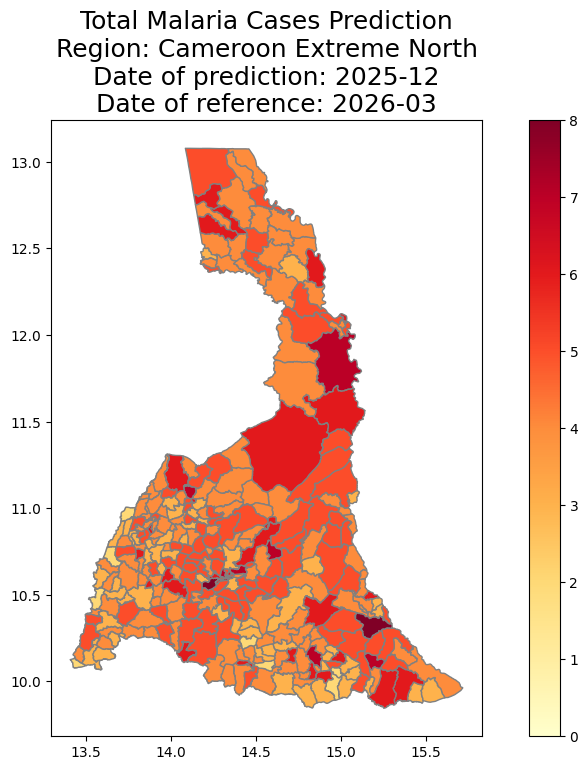

In [39]:
float_column = 'prediction'
cmap = plt.cm.YlOrRd
figure_size = (12,8)
title_size = 18

fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results_shapefile.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = results_shapefile.classes_range.iloc[1])
plt.title(f'{target_variable[ΤARGET]} Prediction\nRegion: Cameroon Extreme North\nDate of prediction: {results_shapefile.dt_prediction.iloc[1]}\nDate of reference: {results_shapefile.dt_reference.iloc[1]}', 
          size = title_size)
# plt.show()